# Day 9 — Model Explainability

## Objective

The objective of this notebook is to interpret the behaviour of the trained sales forecasting models and identify the features that most strongly influence their predictions.

The analysis includes:

- Linear Regression coefficient analysis
- Random Forest feature importance
- XGBoost feature importance
- Cross-model feature comparison
- Business interpretation of influential forecasting features
- Explanation of the final model-selection decision

## Import Libraries

Import the libraries required for loading the forecasting dataset, trained models, generating explanations, and creating visualisations.

In [1]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## Define Project Paths

The notebook is located inside the `notebooks` folder. The following paths provide access to the processed forecasting dataset, trained models, and chart output directory.

In [2]:
BASE_DIR = Path.cwd().parent

DATA_PATH = BASE_DIR / "data" / "processed" / "forecast_features.csv"
MODELS_DIR = BASE_DIR / "models"
CHARTS_DIR = BASE_DIR / "charts"

LINEAR_MODEL_PATH = MODELS_DIR / "linear_regression.pkl"
RANDOM_FOREST_PATH = MODELS_DIR / "random_forest.pkl"
XGBOOST_PATH = MODELS_DIR / "xgboost.pkl"

CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print("Base directory:", BASE_DIR)
print("Dataset path:", DATA_PATH)
print("Models directory:", MODELS_DIR)
print("Charts directory:", CHARTS_DIR)

Base directory: c:\Users\ASUS\SalesForecasting_AnushkaDas
Dataset path: c:\Users\ASUS\SalesForecasting_AnushkaDas\data\processed\forecast_features.csv
Models directory: c:\Users\ASUS\SalesForecasting_AnushkaDas\models
Charts directory: c:\Users\ASUS\SalesForecasting_AnushkaDas\charts


## Load Forecasting Dataset

The engineered forecasting dataset contains calendar, lag, and rolling-average features used during model training.

In [3]:
forecast_df = pd.read_csv(DATA_PATH)

forecast_df["Order Date"] = pd.to_datetime(
    forecast_df["Order Date"]
)

print("Dataset loaded successfully.")
print("Dataset shape:", forecast_df.shape)

forecast_df.head()

Dataset loaded successfully.
Dataset shape: (1200, 15)


,Order Date,Sales,Year,Month,Quarter,Week,Day,DayOfWeek,DayOfYear,IsWeekend,Lag_1,Lag_7,Lag_30,Rolling_Mean_7,Rolling_Mean_30
0,2015-02-14,576.726,2015,2,1,7,14,5,45,1,129.568,97.112,16.448,487.067143,612.546233
1,2015-02-15,21.360,2015,2,1,7,15,6,46,1,576.726,134.384,288.060,470.920857,603.656233
2,2015-02-16,9.040,2015,2,1,8,16,0,47,0,21.360,330.512,19.536,424.996286,603.306367
3,2015-02-17,54.208,2015,2,1,8,17,1,48,0,9.040,180.320,4407.100,406.980286,458.209967
4,2015-02-18,37.784,2015,2,1,8,18,2,49,0,54.208,14.560,87.158,410.298000,456.564167


## Prepare Features and Target

The `Sales` column is the prediction target, while `Order Date` is excluded because the models were trained using the numerical features derived from the date.

In [4]:
X = forecast_df.drop(
    columns=[
        "Order Date",
        "Sales"
    ]
)

y = forecast_df["Sales"]

feature_names = X.columns.tolist()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nModel features:")

for feature in feature_names:
    print("-", feature)

Feature matrix shape: (1200, 13)
Target shape: (1200,)

Model features:
- Year
- Month
- Quarter
- Week
- Day
- DayOfWeek
- DayOfYear
- IsWeekend
- Lag_1
- Lag_7
- Lag_30
- Rolling_Mean_7
- Rolling_Mean_30


## Load Trained Models

The three previously trained forecasting models are loaded from the `models` directory:

- Linear Regression
- Random Forest Regressor
- XGBoost Regressor

In [5]:
with open(LINEAR_MODEL_PATH, "rb") as file:
    linear_model = pickle.load(file)

with open(RANDOM_FOREST_PATH, "rb") as file:
    random_forest_model = pickle.load(file)

with open(XGBOOST_PATH, "rb") as file:
    xgboost_model = pickle.load(file)

print("Models loaded successfully.")
print("Linear Regression:", type(linear_model).__name__)
print("Random Forest:", type(random_forest_model).__name__)
print("XGBoost:", type(xgboost_model).__name__)

Models loaded successfully.
Linear Regression: LinearRegression
Random Forest: RandomForestRegressor
XGBoost: XGBRegressor


## Linear Regression Coefficient Analysis

Linear Regression represents predictions as a weighted combination of input features.

A positive coefficient indicates that an increase in the feature is associated with an increase in predicted sales, while a negative coefficient indicates an inverse relationship.

Because the features use different numerical scales, coefficient magnitude should be interpreted cautiously. The coefficients are still useful for understanding the direction and relative influence of each feature within the fitted model.

In [6]:
linear_explanation = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": linear_model.coef_
})

linear_explanation["Absolute Coefficient"] = (
    linear_explanation["Coefficient"].abs()
)

linear_explanation = linear_explanation.sort_values(
    by="Absolute Coefficient",
    ascending=False
).reset_index(drop=True)

linear_explanation

,Feature,Coefficient,Absolute Coefficient
0,IsWeekend,731.177344,731.177344
1,Month,149.557008,149.557008
2,DayOfWeek,-118.501546,118.501546
3,Quarter,111.082280,111.082280
4,Year,40.424201,40.424201
5,Week,-11.871428,11.871428
6,Day,-5.034918,5.034918
7,DayOfYear,-3.038350,3.038350
8,Rolling_Mean_7,1.009932,1.009932
9,Lag_1,-0.130670,0.130670


## Visualise Linear Regression Coefficients

The chart below displays the coefficient assigned to each forecasting feature. Features farther from zero have a stronger influence on the model prediction.

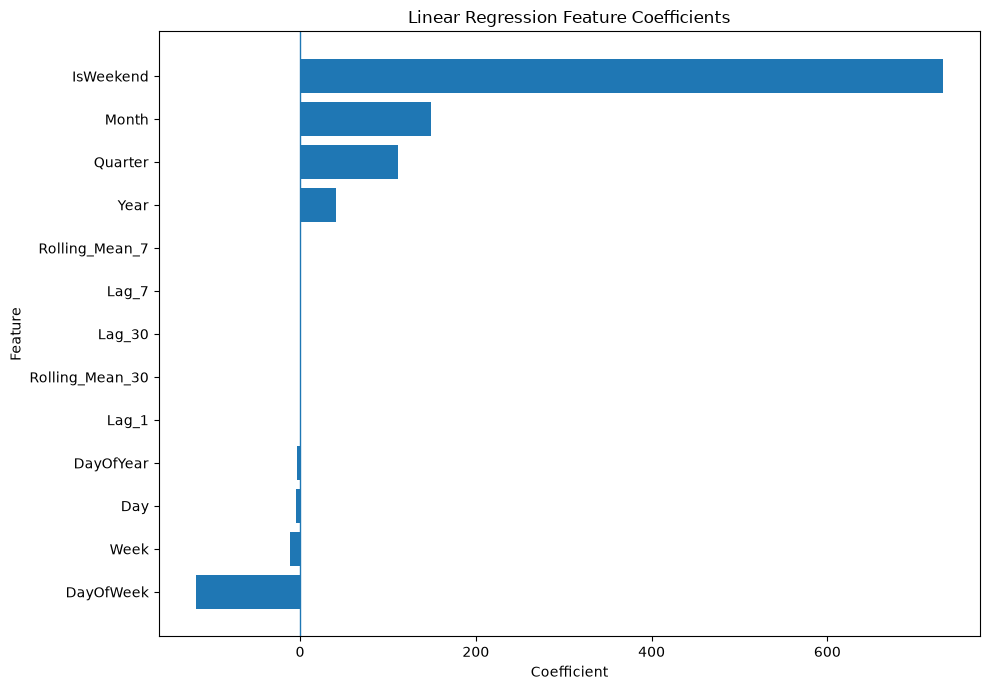

In [7]:
linear_plot_data = linear_explanation.sort_values(
    by="Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    linear_plot_data["Feature"],
    linear_plot_data["Coefficient"]
)

plt.title("Linear Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.axvline(
    x=0,
    linewidth=1
)

plt.tight_layout()
plt.show()

## Random Forest Feature Importance

Unlike Linear Regression, Random Forest does not use coefficients.

Instead, it estimates how much each feature contributes to reducing prediction error across all trees in the ensemble.

Higher feature importance indicates that the feature played a greater role in forecasting sales.

In [8]:
random_forest_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest_model.feature_importances_
})

random_forest_importance = (
    random_forest_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

random_forest_importance

,Feature,Importance
0,Rolling_Mean_7,0.346435
1,Lag_7,0.132329
2,Lag_1,0.121527
3,Lag_30,0.089815
4,Day,0.088026
5,Rolling_Mean_30,0.078006
6,DayOfYear,0.045939
7,DayOfWeek,0.042652
8,Week,0.020423
9,Year,0.019464


## Visualise Random Forest Feature Importance

The following chart ranks forecasting features according to their contribution within the Random Forest model.

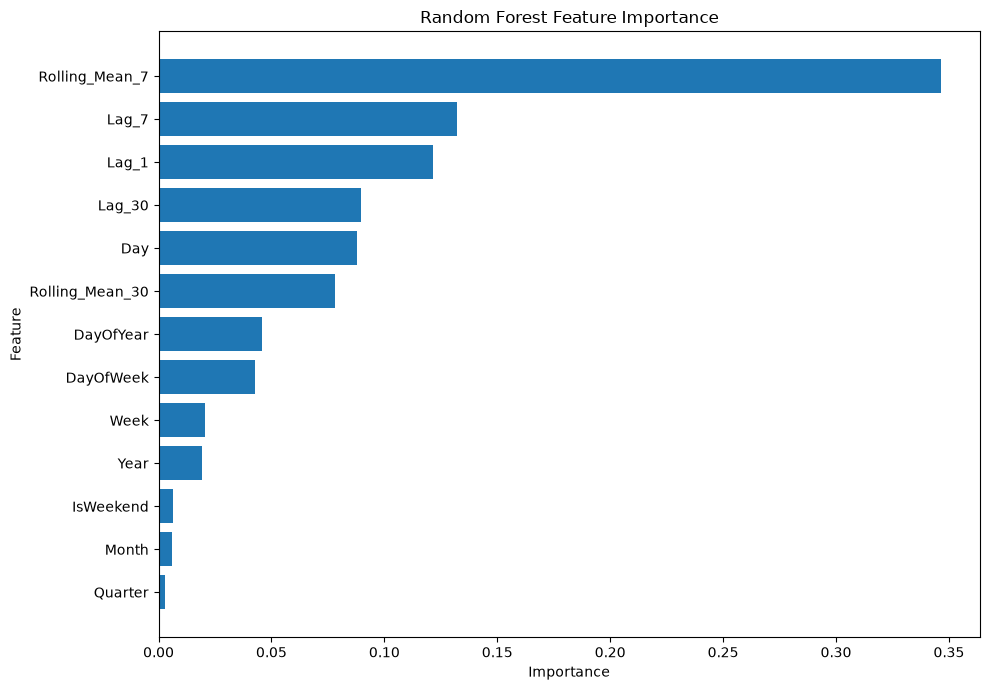

In [9]:
rf_plot = random_forest_importance.sort_values(
    by="Importance"
)

plt.figure(figsize=(10,7))

plt.barh(
    rf_plot["Feature"],
    rf_plot["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

## XGBoost Feature Importance

XGBoost calculates feature importance based on the contribution of each feature during gradient boosting.

More important variables are used more frequently to create effective splits that reduce prediction error.

In [10]:
xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgboost_model.feature_importances_
})

xgb_importance = (
    xgb_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

xgb_importance

,Feature,Importance
0,Rolling_Mean_7,0.184755
1,Rolling_Mean_30,0.090902
2,IsWeekend,0.087890
3,DayOfYear,0.082893
4,Lag_30,0.082330
5,DayOfWeek,0.082121
6,Lag_7,0.080846
7,Lag_1,0.080347
8,Day,0.069591
9,Week,0.060787


## Visualise XGBoost Feature Importance

The chart below illustrates the relative contribution of each forecasting feature within the XGBoost model.

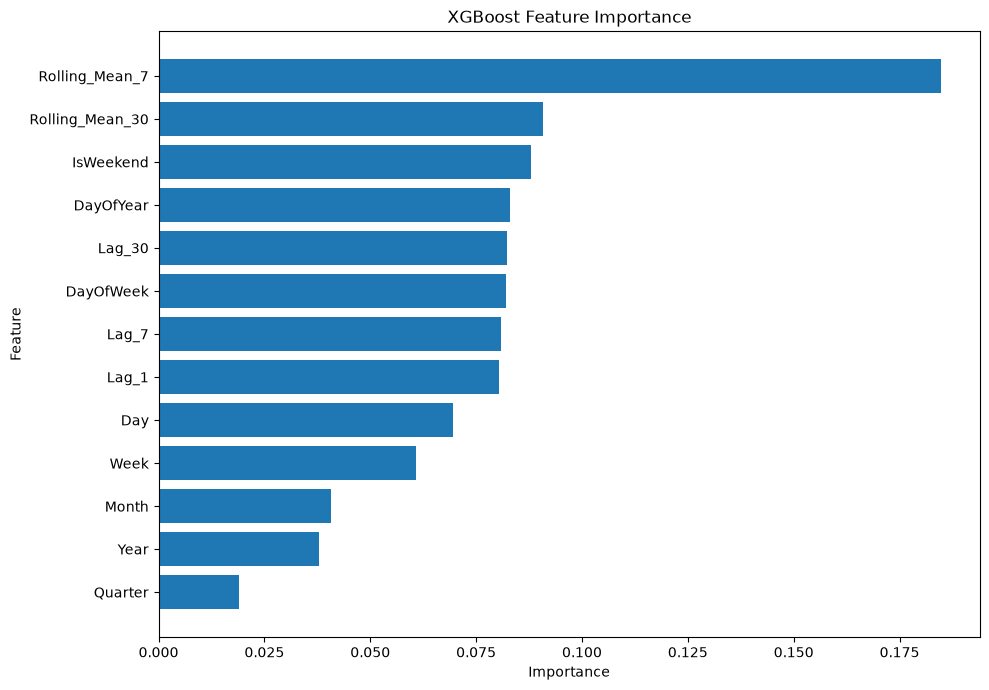

In [11]:
xgb_plot = xgb_importance.sort_values(
    by="Importance"
)

plt.figure(figsize=(10,7))

plt.barh(
    xgb_plot["Feature"],
    xgb_plot["Importance"]
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

## Compare Feature Importance Across Models

Each forecasting model estimates feature importance differently.

- Linear Regression uses coefficients.
- Random Forest uses impurity reduction across decision trees.
- XGBoost measures contribution during gradient boosting.

The comparison below allows us to identify features that consistently influence sales forecasting regardless of the underlying learning algorithm.

In [16]:
comparison = pd.DataFrame({
    "Feature": feature_names,
    "Linear Regression": np.abs(linear_model.coef_),
    "Random Forest": random_forest_model.feature_importances_,
    "XGBoost": xgboost_model.feature_importances_
})

comparison["Linear Regression"] = (
    comparison["Linear Regression"] /
    comparison["Linear Regression"].max()
)

comparison["Random Forest"] = (
    comparison["Random Forest"] /
    comparison["Random Forest"].max()
)

comparison["XGBoost"] = (
    comparison["XGBoost"] /
    comparison["XGBoost"].max()
)

comparison = comparison.sort_values(
    by="XGBoost",
    ascending=False
)

comparison

,Feature,Linear Regression,Random Forest,XGBoost
11,Rolling_Mean_7,0.001381,1.000000,1.000000
12,Rolling_Mean_30,0.000123,0.225168,0.492015
7,IsWeekend,1.000000,0.018197,0.475708
6,DayOfYear,0.004155,0.132603,0.448664
10,Lag_30,0.000005,0.259256,0.445618
5,DayOfWeek,0.162069,0.123115,0.444485
9,Lag_7,0.000036,0.381974,0.437587
8,Lag_1,0.000179,0.350792,0.434886
4,Day,0.006886,0.254092,0.376668
3,Week,0.016236,0.058950,0.329013


## Feature Importance Comparison Chart

The following grouped bar chart compares feature importance estimated by all three forecasting models.

The importance values have been normalized so that the most influential feature in each model has a value of 1.0. This allows a fair visual comparison across Linear Regression, Random Forest, and XGBoost despite their different methods of estimating feature importance.

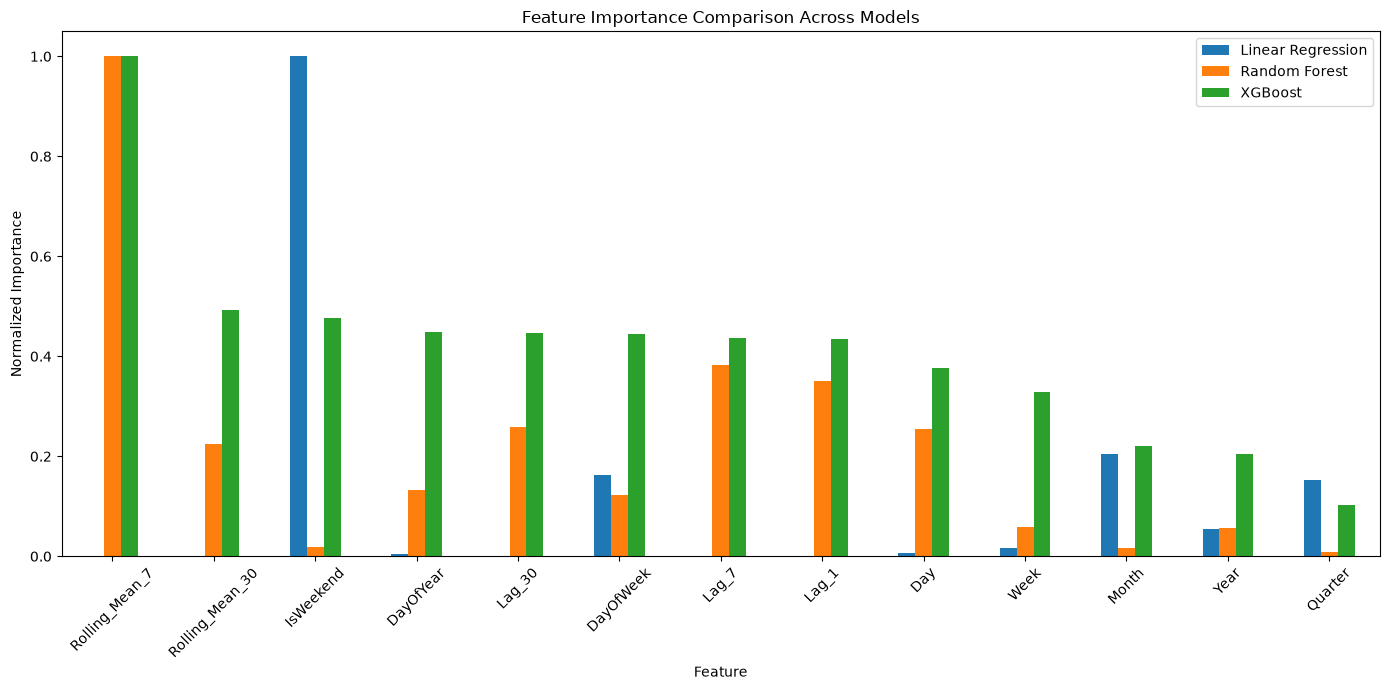

In [20]:
comparison_plot = comparison.set_index("Feature")

comparison_plot.plot(
    kind="bar",
    figsize=(14,7)
)

plt.title("Feature Importance Comparison Across Models")
plt.xlabel("Feature")
plt.ylabel("Normalized Importance")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Business Interpretation

The feature importance analysis demonstrates that different machine learning algorithms prioritize forecasting variables in different ways. To enable a fair comparison, the importance values for each model were normalized so that the most influential feature within each model has a value of **1.0**.

Key observations include:

- **Linear Regression** assigns relatively greater importance to calendar-based variables such as **IsWeekend**, **Month**, and **Quarter**, suggesting that it primarily captures seasonal and time-dependent trends.
- **Random Forest** places the highest emphasis on **Rolling_Mean_7** and other lag-based variables, indicating that recent historical sales have the strongest influence on future predictions.
- **XGBoost** also identifies **Rolling_Mean_7** as the most important predictor while distributing importance more evenly across lag features, rolling averages, and temporal variables, demonstrating its ability to capture complex nonlinear relationships.

Across all three models, **rolling averages and lag features consistently rank among the most influential predictors**, confirming that recent sales behaviour is the strongest indicator of future sales performance.

Overall, the explainability analysis supports the selection of **XGBoost** as the final forecasting model. It effectively balances historical sales information with temporal patterns while achieving the best predictive performance, making it the most suitable model for accurate sales forecasting.

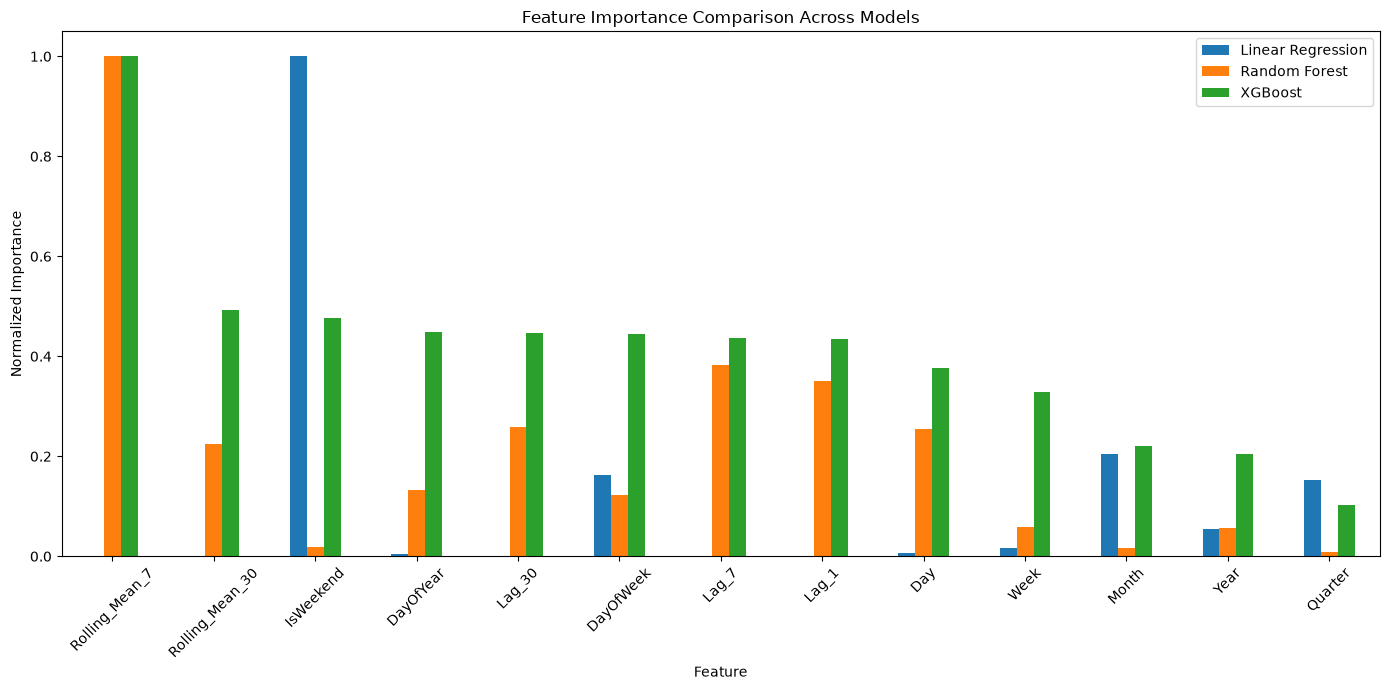

In [21]:
comparison_plot = comparison.set_index("Feature")

ax = comparison_plot.plot(
    kind="bar",
    figsize=(14,7)
)

plt.title("Feature Importance Comparison Across Models")
plt.xlabel("Feature")
plt.ylabel("Normalized Importance")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "model_explainability_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()